In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn tensorflow spacy nltk

!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 3.6 MB/s eta 0:00:04
     ------ --------------------------------- 2.1/12.8 MB 3.9 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 4.9 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 4.2 MB/s eta 0:00:03
     -------------- ------------------------- 4.7/12.8 MB 4.5 MB/s eta 0:00:02
     ----------------- ---------------------- 5.5/12.8 MB 4.3 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 4.4 MB/s eta 0:00:02
     ---------------------------- ----------- 9.2/12.8 MB 5.1 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 5.3 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.8 MB 5.5 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 5.6 M

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import re
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\benan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv(r"C:\Users\benan\OneDrive\Desktop\ML_Poject\BBC news dataset.csv")

df.head()

,Unnamed: 0,description,tags
0,0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,..."
1,1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ..."
2,2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,..."
3,3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'..."
4,4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta..."


In [4]:
print(df.shape)

print(df.columns)

print(df.isnull().sum())

(2410, 3)
Index(['Unnamed: 0', 'description', 'tags'], dtype='object')
Unnamed: 0      0
description     0
tags           18
dtype: int64


In [5]:
df["word_count"] = df["description"].astype(str).apply(
    lambda x: len(x.split())
)

df["word_count"].describe()

count    2410.000000
mean      384.135270
std       225.974416
min        11.000000
25%       246.000000
50%       334.000000
75%       473.000000
max      2910.000000
Name: word_count, dtype: float64

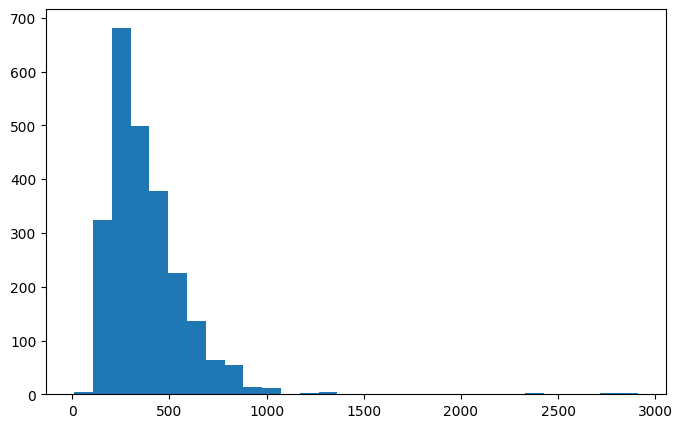

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["word_count"],bins=30)

plt.show()

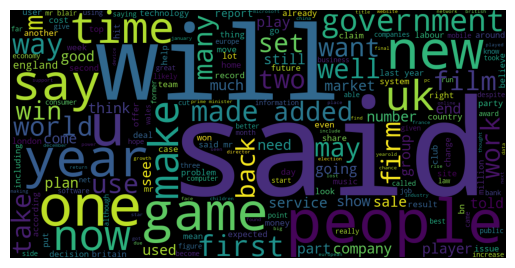

In [7]:
all_text = " ".join(df["description"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(all_text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [8]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [9]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]',' ',text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [10]:
df["clean_text"] = df["description"].apply(
    clean_text
)

In [11]:
df["label"] = df["tags"].apply(
    lambda x:str(x).split(",")[0]
)

df["label"].value_counts()

label
sports           473
entertainment    413
business         399
technology       391
politics         294
                ... 
charlie's          1
saudi arabia       1
afp                1
sweden             1
agroflora          1
Name: count, Length: 120, dtype: int64

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [16]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    df["clean_text"]
)

In [17]:
sequences = tokenizer.texts_to_sequences(
    df["clean_text"]
)

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [19]:
X_dl = pad_sequences(
    sequences,
    maxlen=100,
    padding="post"
)

In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_dl = encoder.fit_transform(
    df["label"]
)

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42
)

In [22]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

In [23]:
model = Sequential()

In [24]:
model.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=100
    )
)

C:\Users\benan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [25]:
model.add(
    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    )
)

In [26]:
model.add(Dropout(0.3))

model.add(Dense(64,activation="relu"))

model.add(
    Dense(
        len(np.unique(y_dl)),
        activation="softmax"
    )
)

In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 165ms/step - accuracy: 0.1719 - loss: 3.6536 - val_accuracy: 0.1295 - val_loss: 2.6319
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.1952 - loss: 2.5127 - val_accuracy: 0.1813 - val_loss: 2.6099
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.3294 - loss: 2.3456 - val_accuracy: 0.1969 - val_loss: 2.5188
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.4786 - loss: 2.0149 - val_accuracy: 0.5596 - val_loss: 1.9780
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.6958 - loss: 1.5134 - val_accuracy: 0.7124 - val_loss: 1.6010


In [29]:
loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print(accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7303 - loss: 1.5072
0.7302904725074768


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000
)

X_ml = vectorizer.fit_transform(
    df["clean_text"]
)

In [31]:
X_train_ml,X_test_ml,y_train_ml,y_test_ml = train_test_split(
    X_ml,
    y_dl,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_ml,
    y_train_ml
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
from sklearn.metrics import accuracy_score

pred = rf.predict(
    X_test_ml
)

print(
    accuracy_score(
        y_test_ml,
        pred
    )
)

0.8381742738589212


In [34]:
import spacy

nlp = spacy.load(
    "en_core_web_sm"
)

In [35]:
sample = df["description"].iloc[0]

doc = nlp(sample)

for ent in doc.ents:
    print(ent.text,ent.label_)

october DATE
last season DATE
zero CARDINAL
six CARDINAL
first ORDINAL
five CARDINAL
stamford bridge FAC
first ORDINAL
english LANGUAGE
fifa ORG
michelle verroken PERSON
october DATE
the romanian international later ORG


In [36]:
for token in doc:
    print(token.text,token.pos_)

chelsea PROPN
sack PROPN
mutu PROPN
  SPACE
chelsea NOUN
have AUX
sacked VERB
adrian ADJ
mutu PROPN
after SCONJ
he PRON
failed VERB
a DET
drugs NOUN
test NOUN
  SPACE
the DET
yearold PROPN
tested VERB
positive ADJ
for ADP
a DET
banned VERB
substance NOUN
  SPACE
which PRON
he PRON
later ADV
denied VERB
was AUX
cocaine NOUN
  SPACE
in ADP
october PROPN
chelsea NOUN
have AUX
decided VERB
to PART
write VERB
off ADP
a DET
possible ADJ
transfer NOUN
fee NOUN
for ADP
mutu PROPN
a DET
m AUX
signing VERB
from ADP
parma NOUN
last ADJ
season NOUN
who PRON
may AUX
face VERB
a DET
twoyear NOUN
suspension NOUN
a DET
statement NOUN
from ADP
chelsea NOUN
explaining VERB
the DET
decision NOUN
readwe NOUN
want VERB
to PART
make VERB
clear ADJ
that SCONJ
chelsea NOUN
has AUX
a DET
zero NUM
tolerance NOUN
policy NOUN
towards ADP
drugs NOUN
mutu PROPN
scored VERB
six NUM
goals NOUN
in ADP
his PRON
first ADJ
five NUM
games NOUN
after ADP
arriving VERB
at ADP
stamford PROPN
bridge PROPN
but CCONJ
his PRON
f

In [37]:
for token in doc:
    print(
        token.text,
        token.dep_,
        token.head.text
    )

chelsea compound sack
sack compound chelsea
mutu compound chelsea
  dep mutu
chelsea nsubj sacked
have aux sacked
sacked ROOT sacked
adrian amod mutu
mutu dobj sacked
after mark failed
he nsubj failed
failed advcl sacked
a det drugs
drugs compound test
test xcomp failed
  dep test
the det yearold
yearold nsubj was
tested amod positive
positive amod yearold
for prep positive
a det substance
banned amod substance
substance pobj for
  dep substance
which dobj denied
he nsubj denied
later advmod denied
denied relcl substance
was conj sacked
cocaine nsubj decided
  dep cocaine
in prep cocaine
october compound chelsea
chelsea pobj in
have aux decided
decided ccomp was
to aux write
write xcomp decided
off prt write
a det fee
possible amod fee
transfer compound fee
fee dobj write
for prep write
mutu pobj for
a det signing
m aux signing
signing conj write
from prep signing
parma pobj from
last amod season
season npadvmod signing
who nsubj face
may aux face
face relcl signing
a det suspension
tw

In [38]:
def generate_questions(text):

    doc = nlp(text)

    questions = []

    for token in doc:

        if token.dep_ == "nsubj":

            subject = token.text

            verb = token.head.text

            questions.append(
                f"Who {verb}?"
            )

    for ent in doc.ents:

        if ent.label_ == "DATE":

            questions.append(
                f"When did this happen ({ent.text})?"
            )

        elif ent.label_ == "GPE":

            questions.append(
                f"Where is {ent.text} located?"
            )

        elif ent.label_ == "ORG":

            questions.append(
                f"What is {ent.text}?"
            )

    return list(set(questions))

In [39]:
sample = df["description"].iloc[20]

questions = generate_questions(sample)

for q in questions:
    print(q)

Who think?
When did this happen (monday)?
Who opens?
Who changed?
When did this happen (next year)?
Who give?
When did this happen (the year)?
Who won?
Who suit?
Where is italy located?
Who begins?
When did this happen (the following week)?
Who told?
Who saw?
When did this happen (january)?
Who includes?
When did this happen (the best year)?
Where is us located?
When did this happen (august)?
Who reach?
Who s?
Who felt?
